# Morocco Calibration Workflow

**A practical companion to `morocco_calibration_guide.md`.**

This notebook walks you through the full calibration process: build inputs, verify them, run the model, diagnose errors, fix parameters, and track progress across iterations.

**Pipeline:** `apply_step0_verified.py` → preflight gates → `apply_step1_calibration.py` → `run_calibration0.py` → `compare_to_inventory.py`

| I want to... | Go to |
|---|---|
| Build df_input_0.csv from template | Section 1: Build Inputs |
| Check my inputs before running | Section 2: Preflight Gates |
| Run the model | Section 3: Calibrate & Run |
| See what's wrong | Section 4: Diagnostic Dashboard |
| Explore a specific parameter | Section 5: Parameter Inspector |
| Fix a calibration error | Section 6: Fix Workflow |
| Compare across runs | Section 7: Iteration Tracker |
| Look up reference data | Section 8: Reference Data Browser |
| Understand sector dependencies | Section 9: DAG Explorer |

In [1]:
import subprocess, sys, glob, json, os, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
%matplotlib inline

# Path detection
try:
    PROJECT_DIR = Path(subprocess.check_output(
        ['git', 'rev-parse', '--show-toplevel'], text=True).strip())
except Exception:
    PROJECT_DIR = Path('.').resolve().parent.parent

SSP_DIR = PROJECT_DIR / 'ssp_modeling'
INPUT_DIR = SSP_DIR / 'input_data'
OUTPUT_DIR = SSP_DIR / 'ssp_run_output'
NOTEBOOKS_DIR = SSP_DIR / 'notebooks'
SCRIPTS_DIR = SSP_DIR / 'output_postprocessing' / 'scripts'
TARGETS_DIR = SSP_DIR / 'output_postprocessing' / 'data' / 'invent'
EXTERNAL_DIR = PROJECT_DIR / 'external_data'
CONFIG_DIR = SSP_DIR / 'config_files'

# Add scripts to path for compare_to_inventory import
sys.path.insert(0, str(SCRIPTS_DIR))

print(f"Project: {PROJECT_DIR}")
print(f"Input:   {INPUT_DIR}")
print(f"Output:  {OUTPUT_DIR}")
for p in [INPUT_DIR, OUTPUT_DIR, SCRIPTS_DIR, EXTERNAL_DIR]:
    assert p.exists(), f"Missing: {p}"
print("All paths OK.")

Project: /Users/jrojasa/Documents/GitHub/ssp_morocco_calibrated
Input:   /Users/jrojasa/Documents/GitHub/ssp_morocco_calibrated/ssp_modeling/input_data
Output:  /Users/jrojasa/Documents/GitHub/ssp_morocco_calibrated/ssp_modeling/ssp_run_output
All paths OK.


In [ ]:
# Load config
import yaml
config_path = CONFIG_DIR / 'config.yaml'
with open(config_path) as f:
    config = yaml.safe_load(f)

COUNTRY = config.get('country_name', 'morocco')
COUNTRY_CODE = config.get('country_code', COUNTRY[:3].upper())
INPUT_FILE = config.get('ssp_input_file_name', 'df_input_0.csv')
ENERGY_FLAG = config.get('energy_model_flag', True)
print(f"Country: {COUNTRY} ({COUNTRY_CODE})")
print(f"Input file: {INPUT_FILE}")
print(f"Energy model: {ENERGY_FLAG}")

In [ ]:
# Load input CSV and targets
df = pd.read_csv(INPUT_DIR / INPUT_FILE)
print(f"Input CSV: {INPUT_FILE} — {len(df)} rows x {len(df.columns)} columns")

# Find targets file
targets_files = sorted(TARGETS_DIR.glob('emission_targets_*.csv'))
TARGETS_FILE = targets_files[-1] if targets_files else None
if TARGETS_FILE:
    targets = pd.read_csv(TARGETS_FILE)
    print(f"Targets:  {TARGETS_FILE.name} ({len(targets)} categories)")
else:
    print("WARNING: No targets file found in", TARGETS_DIR)
    targets = None

In [ ]:
# Country parameterization (COUNTRY_CODE loaded from config in cell 2)
CALIBRATION_TP = 7   # tp=7 = 2022
BASE_YEAR = 2015
N_TP = len(df)
print(f"Country: {COUNTRY_CODE}, Base year: {BASE_YEAR}, Calibration year: {BASE_YEAR + CALIBRATION_TP}, Time periods: {N_TP}")

---
# Section 1: Build Inputs

Run `apply_step0_verified.py` first — it builds `df_input_0.csv` from the raw template + external data. **Preflight gates check the values in this file**, so it must exist before checking.

In [5]:
# Run step0 to build df_input_0.csv from raw template + external data
PYTHON = sys.executable

def run_script(name, script_path):
    print(f"Running {name}...")
    result = subprocess.run([PYTHON, str(script_path)], capture_output=True, text=True, cwd=str(PROJECT_DIR))
    if result.returncode != 0:
        print(f"  ERROR: {result.stderr[-500:]}")
    else:
        lines = result.stdout.strip().split('\n')
        for line in lines[-5:]:
            print(f"  {line}")
    return result.returncode == 0

run_script("apply_step0_verified", NOTEBOOKS_DIR / "apply_step0_verified.py")

# Reload df after step0
df = pd.read_csv(INPUT_DIR / 'df_input_0.csv')
print(f"\nReloaded df_input_0.csv: {len(df)} rows x {len(df.columns)} columns")

Running apply_step0_verified...
  inf: 0, NaN: 0
  Saved to /Users/jrojasa/Documents/GitHub/ssp_morocco_calibrated/ssp_modeling/input_data/df_input_0.csv
  
  Remaining for calibration loop: §6.7 ENTC (MSP, efficiency, capacity), §6.10 WW

Reloaded df_input_0.csv: 56 rows x 2420 columns


In [6]:
# Gate 1: Population
def check_gate(name, model_val, ref_val, tolerance=0.05):
    err = abs(model_val - ref_val) / ref_val
    status = "PASS" if err < tolerance else "FAIL"
    print(f"  {status:4s} | {name:35s} | Model: {model_val:>15,.0f} | Reference: {ref_val:>15,.0f} | Error: {err:.1%}")
    return status == "PASS"

results = []
print("=" * 100)
print("  PREFLIGHT GATES")
print("=" * 100)

# Gate 1: Population
pop_model = df['population_gnrl_rural'].iloc[0] + df['population_gnrl_urban'].iloc[0]
try:
    wb_pop = pd.read_csv(EXTERNAL_DIR / 'world_bank' / f'{COUNTRY.lower()}_population_total.csv')
    pop_ref = wb_pop[wb_pop.columns[-1]].iloc[-1] if 'Value' not in wb_pop.columns else wb_pop.loc[wb_pop['Year'] == BASE_YEAR, 'Value'].iloc[0]
    # Try to find 2015 population
    for col in wb_pop.columns:
        if str(BASE_YEAR) in str(col):
            pop_ref = wb_pop[col].iloc[0]
            break
    results.append(check_gate("Gate 1: Population", pop_model, pop_ref))
except Exception as e:
    print(f"  SKIP | Gate 1: Population — {e}")
    results.append(None)

  PREFLIGHT GATES
  FAIL | Gate 1: Population                  | Model:      34,607,588 | Reference:      37,329,064 | Error: 7.3%


---
# Section 2: Preflight Gates

**Why:** Wrong population cascades to every sector. Wrong GDP scale invalidates all energy intensities. These checks verify `df_input_0.csv` (built by step0 above) against external data.

In [7]:
# Gate 2: GDP
gdp_model = df['gdp_mmm_usd'].iloc[0]
print(f"  INFO | Gate 2: GDP = {gdp_model:.2f} billion USD (verify against World Bank)")

# Gate 3: Occupancy
occ = df['occrateinit_gnrl_occupancy'].iloc[0] if 'occrateinit_gnrl_occupancy' in df.columns else None
if occ:
    hh_count = pop_model / occ
    print(f"  INFO | Gate 3: Occupancy = {occ:.2f} → HH count = {hh_count:,.0f}")

# Gate 4: Livestock
print("\n  Gate 4: Livestock Populations")
for species in ['cattle_dairy', 'cattle_nondairy', 'sheep', 'goats', 'chickens', 'horses', 'mules', 'pigs']:
    col = f'pop_lvst_initial_{species}'
    if col in df.columns:
        val = df[col].iloc[0]
        print(f"    {species:20s}: {val:>15,.0f}")

  INFO | Gate 2: GDP = 270.39 billion USD (verify against World Bank)
  INFO | Gate 3: Occupancy = 4.60 → HH count = 7,523,389

  Gate 4: Livestock Populations
    cattle_dairy        :       1,722,276
    cattle_nondairy     :       1,568,774
    sheep               :      18,509,601
    goats               :       6,231,386
    chickens            :     191,140,000
    horses              :         162,000
    mules               :         420,000
    pigs                :           7,979


In [8]:
# Gate 5: Fertilizer
fert_col = 'qtyinit_soil_synthetic_fertilizer_kt'
if fert_col in df.columns:
    print(f"  INFO | Gate 5: Fertilizer = {df[fert_col].iloc[0]:.1f} kt N")

# Gate 7b: Fuel Exports (should be zero for net importers)
print("\n  Gate 7b: Fuel Exports (should be 0 for net importers)")
for col in sorted(c for c in df.columns if c.startswith('exports_enfu_pj_fuel_')):
    val = df[col].iloc[0]
    status = "PASS" if abs(val) < 0.01 else "WARN"
    fuel = col.replace('exports_enfu_pj_fuel_', '')
    if abs(val) > 0.01:
        print(f"    {status} | {fuel:25s}: {val:.2f} PJ")

# Gate 7c: Waste
print("\n  Gate 7c: Waste Baseline")
for col in ['qty_waso_initial_municipal_waste_tonne_per_capita', 'frac_waso_landfill_gas_recovered']:
    if col in df.columns:
        name = col.replace('qty_waso_initial_', '').replace('frac_waso_', '')
        print(f"    {name:40s}: {df[col].iloc[0]:.4f}")

# Gate 10: inf/NaN
n_inf = sum(np.isinf(df[c]).sum() for c in df.select_dtypes(include=[np.number]).columns)
n_nan = df.isna().sum().sum()
status = "PASS" if n_inf == 0 and n_nan == 0 else "FAIL"
print(f"\n  {status} | Gate 10: inf={n_inf}, NaN={n_nan}")

  INFO | Gate 5: Fertilizer = 243.2 kt N

  Gate 7b: Fuel Exports (should be 0 for net importers)

  Gate 7c: Waste Baseline
    municipal_waste_tonne_per_capita        : 0.3550
    landfill_gas_recovered                  : 0.0200

  PASS | Gate 10: inf=0, NaN=0


---
# Section 3: Calibrate & Run

Apply calibration fixes (step1), then run the model. Choose `--no-energy` for fast AFOLU/IPPU checks (~30s) or full mode with NemoMod (~5 min).

In [9]:
# Run step1 (calibration fixes) — step0 already ran in Section 1
run_script("apply_step1_calibration", NOTEBOOKS_DIR / "apply_step1_calibration.py")

# Reload df after step1
df = pd.read_csv(INPUT_DIR / 'df_input_0.csv')
print(f"\nReloaded: {len(df)} rows x {len(df.columns)} columns")

Running apply_step1_calibration...
    EF1: -> 0.030 (IPCC max; back-calc from NIR T83: soil target 6.40 MtCO2e)
    WW treatment: reversed aerobic shift for NIR WW CH4 = 2,948 Gg
    Metals: prod=2,027,000 t, EF=0.147 (NIR T67+T55, set after IEA scaling)
  
    FINAL SAVE to /Users/jrojasa/Documents/GitHub/ssp_morocco_calibrated/ssp_modeling/input_data/df_input_0.csv

Reloaded: 56 rows x 2420 columns


In [ ]:
# Run calibration (choose one)
# Fast mode: --no-energy (~30 sec, tests AFOLU/CircularEconomy/IPPU only)
# Full mode: includes NemoMod energy optimization (~3-5 min)

MODE = "--baseline-only"  # Change to "--baseline-only --no-energy" for fast mode

result = subprocess.run(
    [PYTHON, str(NOTEBOOKS_DIR / "run_calibration.py"), MODE, "--input-file", INPUT_FILE],
    capture_output=True, text=True, cwd=str(PROJECT_DIR), timeout=600
)
lines = result.stdout.strip().split('\n')
for line in lines[-20:]:
    print(line)

In [11]:
# Find latest run output
runs = sorted(OUTPUT_DIR.glob('calibration_*'))
if runs:
    LATEST_RUN = runs[-1]
    WIDE_PATH = LATEST_RUN / 'WIDE_INPUTS_OUTPUTS.csv'
    print(f"Latest run: {LATEST_RUN.name}")
    print(f"WIDE file:  {'EXISTS' if WIDE_PATH.exists() else 'MISSING'}")
    if WIDE_PATH.exists():
        wide = pd.read_csv(WIDE_PATH)
        print(f"  {len(wide)} rows x {len(wide.columns)} columns")
else:
    print("No calibration runs found.")
    LATEST_RUN = None

Latest run: calibration_20260313_224517
WIDE file:  EXISTS
  56 rows x 4054 columns


---
# Section 3: Diagnostic Dashboard

Import the `compare_to_inventory` API to run diagnostics directly in the notebook. Returns DataFrames you can visualize and filter.

**How to read results:**
- `error_pct` = |model - inventory| / |inventory| × 100
- `direction` = "over" (model too high) or "under" (model too low)
- `top_component` = the single largest model output variable in that category

In [12]:
from compare_to_inventory import compare, DiagnosticConfig, DAG_AFFECTS

config = DiagnosticConfig(tp=CALIBRATION_TP, threshold=0.15)
diff, flagged, diag = compare(str(TARGETS_FILE), str(WIDE_PATH), config, verbose=False)

sig = diff[diff['inventory'].abs() > 0.01]
total_err = sig['diff'].abs().sum()
n_15 = (sig['error_pct'] <= 15).sum()
n_25 = (sig['error_pct'] <= 25).sum()
status = "GOOD" if total_err < 10 and n_15 > len(sig) * 0.5 else "NEEDS WORK"
print(f"CALIBRATION: {total_err:.2f} MtCO2e | {n_15}/{len(sig)} within 15% | {status}")

CALIBRATION: 7.29 MtCO2e | 16/34 within 15% | NEEDS WORK


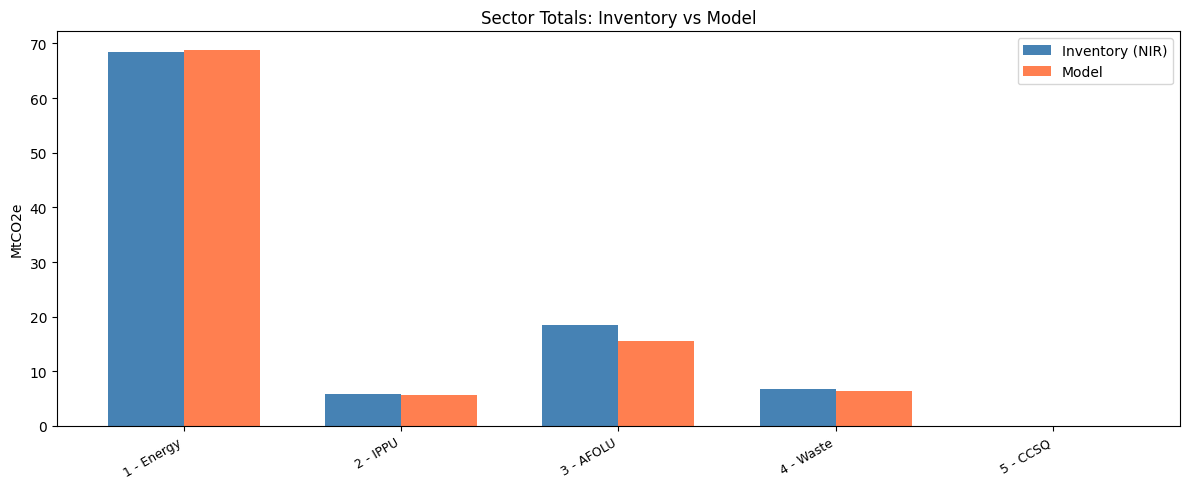

In [13]:
# Sector totals bar chart
sector_data = []
for sec in sorted(diff['sector'].unique()):
    sub = diff[diff['sector'] == sec]
    sector_data.append({'Sector': sec, 'Inventory': sub['inventory'].sum(), 'Model': sub['model'].sum()})
sdf = pd.DataFrame(sector_data)
sdf['Diff'] = sdf['Model'] - sdf['Inventory']

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(sdf))
w = 0.35
ax.bar([i - w/2 for i in x], sdf['Inventory'], w, label='Inventory (NIR)', color='steelblue')
ax.bar([i + w/2 for i in x], sdf['Model'], w, label='Model', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(sdf['Sector'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('MtCO2e')
ax.set_title('Sector Totals: Inventory vs Model')
ax.legend()
ax.axhline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.show()

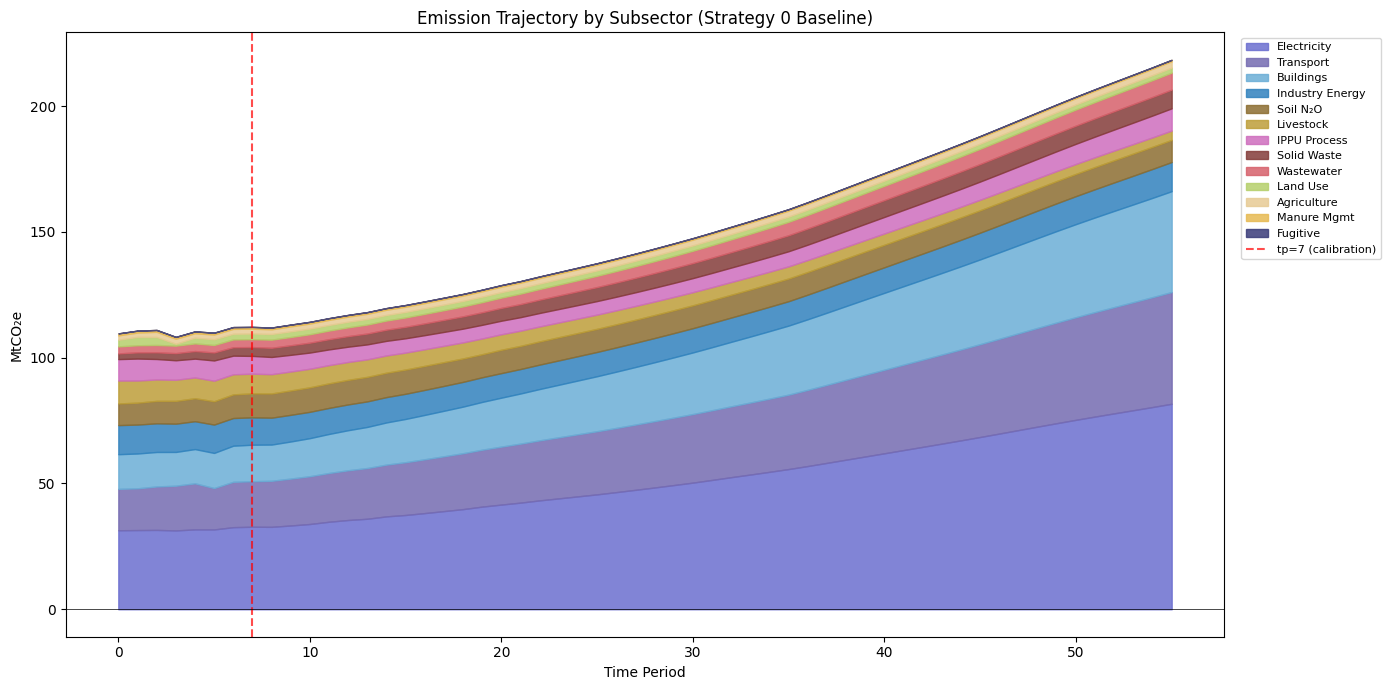

In [14]:
# Stacked emission plot by subsector (full trajectory 2015-2070)
# Uses SISEPUEDE's native color scheme and field names

SUBSECTOR_COLORS = {
    'agrc': '#E7CB94', 'frst': '#31A354', 'lndu': '#B5CF6B',
    'lsmm': '#E7BA52', 'lvst': '#BD9E39', 'soil': '#8C6D31',
    'waso': '#843C39', 'trww': '#D6616B',
    'ccsq': '#C6DBEF', 'entc': '#6B6ECF', 'fgtv': '#393B79',
    'inen': '#3182BD', 'scoe': '#6BAED6', 'trns': '#756BB1',
    'ippu': '#CE6DBD',
}

SUBSECTOR_NAMES = {
    'agrc': 'Agriculture', 'frst': 'Forest', 'lndu': 'Land Use',
    'lsmm': 'Manure Mgmt', 'lvst': 'Livestock', 'soil': 'Soil N₂O',
    'waso': 'Solid Waste', 'trww': 'Wastewater',
    'ccsq': 'CCS', 'entc': 'Electricity', 'fgtv': 'Fugitive',
    'inen': 'Industry Energy', 'scoe': 'Buildings', 'trns': 'Transport',
    'ippu': 'IPPU Process',
}

SECTOR_MAP = {
    'agrc': 'AFOLU', 'frst': 'AFOLU', 'lndu': 'AFOLU',
    'lvst': 'AFOLU', 'lsmm': 'AFOLU', 'soil': 'AFOLU',
    'waso': 'Waste', 'trww': 'Waste',
    'ccsq': 'Energy', 'entc': 'Energy', 'fgtv': 'Energy',
    'inen': 'Energy', 'scoe': 'Energy', 'trns': 'Energy',
    'ippu': 'IPPU',
}

# Compute subsector totals at each time period
subsector_fields = [f'emission_co2e_subsector_total_{s}' for s in SUBSECTOR_COLORS]
available = [f for f in subsector_fields if f in wide.columns]

tp7_row = wide[wide['time_period'] == CALIBRATION_TP].iloc[0]

# === PLOT 1: Full trajectory stacked area ===
fig, ax = plt.subplots(figsize=(14, 7))
years = wide['time_period'].values
data = {f: wide[f].values for f in available if wide[f].sum() > 0}

# Sort by tp=7 value for visual clarity
sorted_fields = sorted(data.keys(), key=lambda f: tp7_row.get(f, 0), reverse=True)

# Separate positive and negative
pos_fields = [f for f in sorted_fields if tp7_row.get(f, 0) >= 0]
neg_fields = [f for f in sorted_fields if tp7_row.get(f, 0) < 0]

# Stack positive
bottom = np.zeros(len(years))
for f in pos_fields:
    abv = f.replace('emission_co2e_subsector_total_', '')
    vals = np.maximum(data[f], 0)  # clip negatives for stacking
    ax.fill_between(years, bottom, bottom + vals, 
                    color=SUBSECTOR_COLORS.get(abv, '#999'),
                    label=SUBSECTOR_NAMES.get(abv, abv), alpha=0.85)
    bottom += vals

# Stack negative (below zero)
bottom_neg = np.zeros(len(years))
for f in neg_fields:
    abv = f.replace('emission_co2e_subsector_total_', '')
    vals = np.minimum(data[f], 0)
    ax.fill_between(years, bottom_neg + vals, bottom_neg,
                    color=SUBSECTOR_COLORS.get(abv, '#999'),
                    label=SUBSECTOR_NAMES.get(abv, abv), alpha=0.85)
    bottom_neg += vals

ax.axvline(CALIBRATION_TP, color='red', linestyle='--', alpha=0.7, label=f'tp={CALIBRATION_TP} (calibration)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Time Period')
ax.set_ylabel('MtCO₂e')
ax.set_title('Emission Trajectory by Subsector (Strategy 0 Baseline)')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8, ncol=1)
plt.tight_layout()
plt.show()

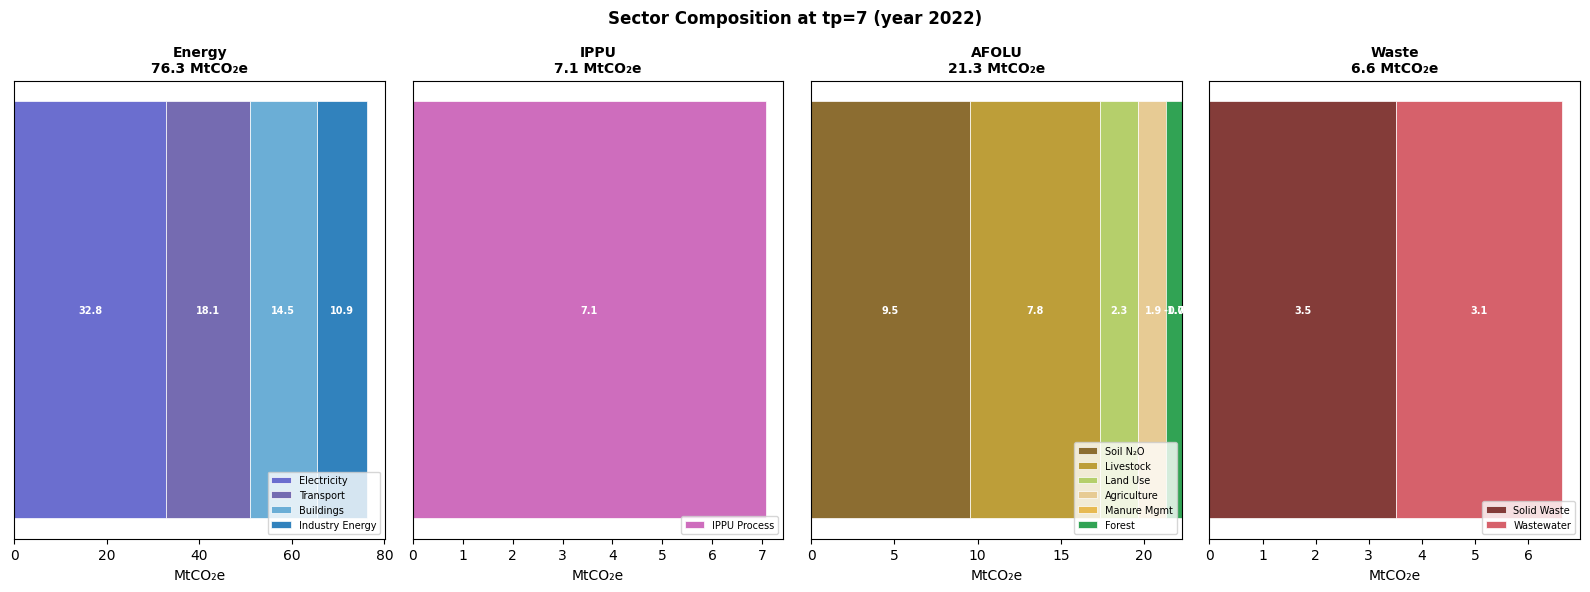

In [15]:
# === PLOT 2: Sector breakdown at calibration year (tp=7) ===
# Grouped by sector, stacked by subsector within each sector

sector_order = ['Energy', 'IPPU', 'AFOLU', 'Waste']
sector_colors = {'Energy': '#3182BD', 'IPPU': '#CE6DBD', 'AFOLU': '#8C6D31', 'Waste': '#843C39'}

fig, axes = plt.subplots(1, 4, figsize=(16, 6), sharey=True)

for ax, sector in zip(axes, sector_order):
    subsectors = [s for s, sec in SECTOR_MAP.items() if sec == sector]
    vals = []
    labels = []
    colors = []
    for s in subsectors:
        f = f'emission_co2e_subsector_total_{s}'
        if f in wide.columns:
            v = tp7_row[f]
            if abs(v) > 0.01:
                vals.append(v)
                labels.append(SUBSECTOR_NAMES.get(s, s))
                colors.append(SUBSECTOR_COLORS.get(s, '#999'))
    
    if vals:
        # Horizontal stacked bar
        left = 0
        for v, label, color in sorted(zip(vals, labels, colors), key=lambda x: -x[0]):
            ax.barh(0, v, left=left, color=color, label=label, edgecolor='white', linewidth=0.5)
            if abs(v) > 0.5:
                ax.text(left + v/2, 0, f'{v:.1f}', ha='center', va='center', fontsize=7, color='white', fontweight='bold')
            left += v
    
    ax.set_title(f'{sector}\n{sum(vals):.1f} MtCO₂e', fontsize=10, fontweight='bold')
    ax.set_yticks([])
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlabel('MtCO₂e')

fig.suptitle(f'Sector Composition at tp={CALIBRATION_TP} (year {BASE_YEAR + CALIBRATION_TP})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

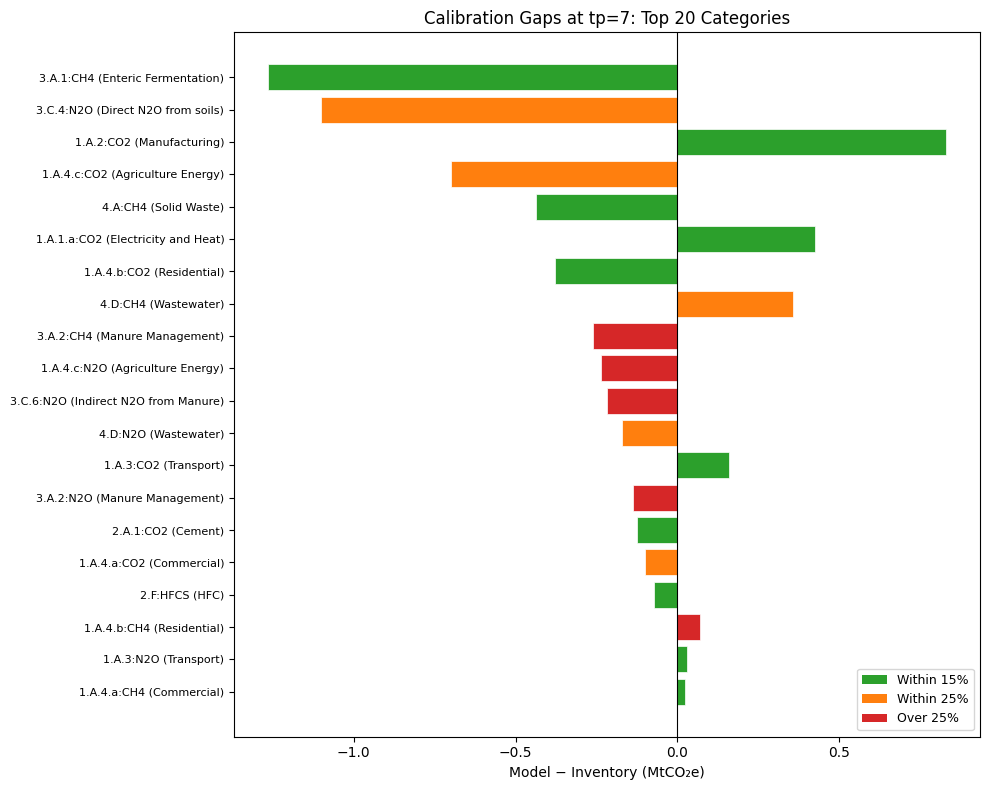

In [16]:
# === PLOT 3: Model vs Inventory — error waterfall by IPCC category ===
# Shows each category's gap: green = within 15%, yellow = within 25%, red = over

if 'diff' in diff.columns:
    plot_data = diff[diff['inventory'].abs() > 0.05].sort_values('diff', key=abs, ascending=True).tail(20)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = []
    for _, row in plot_data.iterrows():
        err = abs(row['error_pct']) if not pd.isna(row['error_pct']) else 100
        if err <= 15:
            colors.append('#2ca02c')  # green
        elif err <= 25:
            colors.append('#ff7f0e')  # orange
        else:
            colors.append('#d62728')  # red
    
    # Category labels with descriptions
    labels = []
    for _, row in plot_data.iterrows():
        cat = str(row.get('category', row['ID']))
        desc = cat.split(' - ', 1)[1] if ' - ' in cat else ''
        labels.append(f"{row['ID']} ({desc})" if desc else str(row['ID']))
    
    ax.barh(range(len(plot_data)), plot_data['diff'].values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(plot_data)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Model − Inventory (MtCO₂e)')
    ax.set_title(f'Calibration Gaps at tp={CALIBRATION_TP}: Top 20 Categories')
    
    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2ca02c', label='Within 15%'),
        Patch(facecolor='#ff7f0e', label='Within 25%'),
        Patch(facecolor='#d62728', label='Over 25%'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print("Run Section 3 diagnostic cells first to generate diff data.")

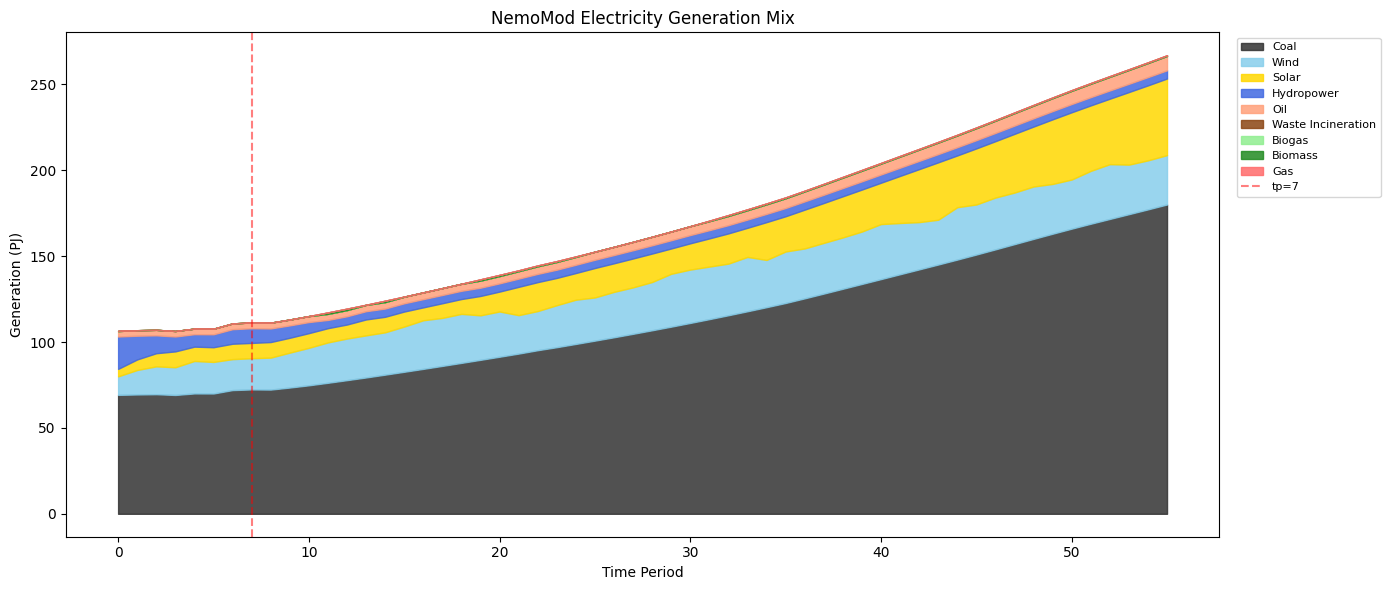

In [17]:
# === PLOT 4: NemoMod Electricity Generation Mix (stacked area over time) ===

gen_cols = [c for c in wide.columns if 'nemomod_entc_annual_production_by_technology_pp_' in c]
if gen_cols:
    TECH_COLORS = {
        'coal': '#333333', 'gas': '#FF6B6B', 'oil': '#FFA07A', 'hydropower': '#4169E1',
        'solar': '#FFD700', 'wind': '#87CEEB', 'biomass': '#228B22', 'biogas': '#90EE90',
        'nuclear': '#DDA0DD', 'geothermal': '#CD853F', 'waste_incineration': '#8B4513',
        'ocean': '#00CED1', 'coal_ccs': '#666666', 'gas_ccs': '#FF9999',
    }
    
    fig, ax = plt.subplots(figsize=(14, 6))
    tps = wide['time_period'].values
    bottom = np.zeros(len(tps))
    
    # Sort by tp=7 production (largest first)
    gen_data = {c: wide[c].values for c in gen_cols if wide[c].sum() > 0}
    tp7_vals = {c: wide.loc[wide['time_period'] == CALIBRATION_TP, c].values[0] for c in gen_data}
    sorted_cols = sorted(gen_data.keys(), key=lambda c: tp7_vals.get(c, 0), reverse=True)
    
    for c in sorted_cols:
        tech = c.replace('nemomod_entc_annual_production_by_technology_pp_', '')
        vals = np.maximum(gen_data[c], 0)
        color = TECH_COLORS.get(tech, '#999999')
        ax.fill_between(tps, bottom, bottom + vals, color=color, label=tech.replace('_', ' ').title(), alpha=0.85)
        bottom += vals
    
    ax.axvline(CALIBRATION_TP, color='red', linestyle='--', alpha=0.5, label=f'tp={CALIBRATION_TP}')
    ax.set_xlabel('Time Period')
    ax.set_ylabel('Generation (PJ)')
    ax.set_title('NemoMod Electricity Generation Mix')
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No NemoMod generation data found. Run with energy_model_flag=True.")

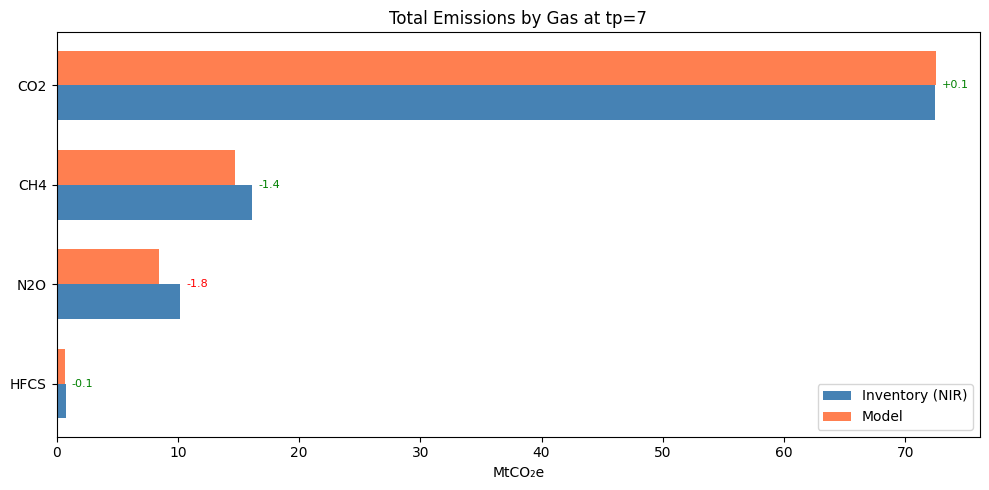

In [18]:
# === PLOT 5: Model vs Inventory by Gas ===

if 'diff' in dir() and len(diff) > 0:
    gas_data = diff.groupby('gas').agg({'inventory': 'sum', 'model': 'sum'}).reset_index()
    gas_data = gas_data[gas_data['inventory'].abs() > 0.1].sort_values('inventory', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(gas_data))
    w = 0.35
    ax.barh([i - w/2 for i in x], gas_data['inventory'], w, label='Inventory (NIR)', color='steelblue')
    ax.barh([i + w/2 for i in x], gas_data['model'], w, label='Model', color='coral')
    ax.set_yticks(x)
    ax.set_yticklabels(gas_data['gas'])
    ax.set_xlabel('MtCO₂e')
    ax.set_title(f'Total Emissions by Gas at tp={CALIBRATION_TP}')
    ax.legend()
    
    # Add error labels
    for i, (_, row) in enumerate(gas_data.iterrows()):
        d = row['model'] - row['inventory']
        ax.text(max(row['model'], row['inventory']) + 0.5, i, f'{d:+.1f}', va='center', fontsize=8,
                color='green' if abs(d)/abs(row['inventory'])*100 < 15 else 'red')
    
    plt.tight_layout()
    plt.show()

In [19]:
# Top flagged categories table
top = flagged.head(10)[['ID', 'category', 'gas', 'inventory', 'model', 'diff', 'error_pct', 'direction', 'top_component']].copy()
top['error_pct'] = top['error_pct'].round(1)
top['diff'] = top['diff'].round(3)
print("Top 10 Flagged Categories (sorted by absolute error):\n")
print(top.to_string(index=False))

Top 10 Flagged Categories (sorted by absolute error):

         ID                         category gas  inventory    model   diff  error_pct direction                                  top_component
  3.C.4:N2O    3.C.4 - Direct N2O from soils N2O   6.397100 5.297036 -1.100       17.2     under                            n2o_soil_fertilizer
1.A.4.c:CO2     1.A.4.c - Agriculture Energy CO2   2.798160 2.099036 -0.699       25.0     under             co2_inen_agriculture_and_livestock
    4.D:CH4                 4.D - Wastewater CH4   2.196040 2.553505  0.357       16.3      over ch4_trww_treated_secondary_anaerobic_treatment
  3.A.2:CH4        3.A.2 - Manure Management CH4   0.561680 0.299888 -0.262       46.6     under                 ch4_lsmm_paddock_pasture_range
1.A.4.c:N2O     1.A.4.c - Agriculture Energy N2O   0.246715 0.010113 -0.237       95.9     under             n2o_inen_agriculture_and_livestock
  3.C.6:N2O 3.C.6 - Indirect N2O from Manure N2O   0.344500 0.125770 -0.219      

In [20]:
# Structural diagnostics
if len(diag) > 0:
    print("Diagnostics:\n")
    for sev in ['HIGH', 'MEDIUM']:
        sev_df = diag[diag['severity'] == sev]
        if len(sev_df) > 0:
            print(f"  {sev} ({len(sev_df)}):")
            for _, w in sev_df.iterrows():
                print(f"    {w['issue']:30s} {w['ID']:25s} {str(w['detail'])[:60]}")
            print()
else:
    print("No diagnostics (all clean).")

Diagnostics:

  HIGH (2):
    ZERO_OUTPUT                    1.A.1.c:CH4               Target=0.0183 but model=0. 3/3 vars zero. Needs input values
    MAGNITUDE_10X                  1.A.4.c:N2O               Ratio=0.0x. Possible unit error or missing parameter.

  MEDIUM (8):
    SINGLE_DOMINANCE               1.A.1.a:CO2               co2_entc_generation_pp_coal is 98% of total. 9 other vars ar
    SINGLE_DOMINANCE               1.A.1.a:N2O               n2o_entc_generation_pp_coal is 96% of total. 10 other vars a
    GROWTH_LAG                     1 - Energy                1 - Energy grows +0.6%/yr vs GDP +1.9%/yr (elasticity=+0.30)
    DECLINING_WITH_GDP_GROWTH      2 - IPPU                  2 - IPPU emissions -3.5%/yr while GDP grows +1.9%/yr (elasti
    POPULATION_MISMATCH            4 - Waste                 4 - Waste grows +32% vs population +8% (4.1x faster).
    GAS_RATIO                      1.A.2:CH4                 CO2 ratio=113% but CH4 ratio=972%. Check CH4 EFs.
    GAS_

In [21]:
# Category inspector — inspect any category in detail
def inspect_category(category_id):
    row = diff[diff['ID'] == category_id]
    if len(row) == 0:
        print(f"Category '{category_id}' not found. Available: {', '.join(diff['ID'].tolist()[:10])}...")
        return
    row = row.iloc[0]
    print(f"Category: {row['ID']}  ({row.get('category', '')})")
    print(f"  Inventory: {row['inventory']:.3f} MtCO2e")
    print(f"  Model:     {row['model']:.3f} MtCO2e")
    print(f"  Diff:      {row['diff']:+.3f} ({row['error_pct']:.1f}% {row['direction']})")
    print(f"  Top component: {row['top_component']}")
    # Show all components
    from compare_to_inventory import get_components, load_model_row
    model_row = load_model_row(WIDE_PATH, CALIBRATION_TP)
    comps = get_components(row.get('vars', ''), model_row, top_n=10)
    if len(comps) > 0:
        print(f"  Components:")
        for _, c in comps.iterrows():
            from compare_to_inventory import short_name
            pct = c['val'] / row['model'] * 100 if abs(row['model']) > 1e-6 else 0
            print(f"    {short_name(c['var']):50s} {c['val']:8.4f}  ({pct:5.1f}%)")

# Example: inspect_category("3.A.1:CH4")
inspect_category("3.A.1:CH4")

Category: 3.A.1:CH4  (3.A.1 - Enteric Fermentation)
  Inventory: 9.100 MtCO2e
  Model:     7.835 MtCO2e
  Diff:      -1.265 (13.9% under)
  Top component: ch4_lvst_entferm_cattle_dairy
  Components:
    ch4_lvst_entferm_cattle_dairy                        3.1910  ( 40.7%)
    ch4_lvst_entferm_sheep                               2.2433  ( 28.6%)
    ch4_lvst_entferm_cattle_nondairy                     1.1783  ( 15.0%)
    ch4_lvst_entferm_goats                               0.7554  (  9.6%)
    ch4_lvst_entferm_horses                              0.3652  (  4.7%)
    ch4_lvst_entferm_mules                               0.1018  (  1.3%)
    ch4_lvst_entferm_pigs                                0.0002  (  0.0%)
    ch4_lvst_entferm_buffalo                             0.0000  (  0.0%)
    ch4_lvst_entferm_chickens                            0.0000  (  0.0%)


---
# Section 4: Parameter Inspector

The input CSV has ~2,420 columns. These tools help you find, inspect, and validate specific parameters.

In [22]:
def search_columns(keyword, tp=0):
    """Search for columns containing a keyword and show their values."""
    matches = [c for c in df.columns if keyword.lower() in c.lower()]
    if not matches:
        print(f"No columns matching '{keyword}'")
        return
    print(f"{len(matches)} columns matching '{keyword}':")
    for c in sorted(matches)[:20]:
        print(f"  {c:70s} tp0={df[c].iloc[0]:.6g}  tp7={df[c].iloc[CALIBRATION_TP]:.6g}")
    if len(matches) > 20:
        print(f"  ... and {len(matches)-20} more")

search_columns("cement")

26 columns matching 'cement':
  consumpinit_inen_energy_tj_per_tonne_production_cement                 tp0=0.00277  tp7=0.00277
  dem_ippu_average_materials_tonne_per_household_cement                  tp0=3  tp7=3
  demscalar_ippu_cement                                                  tp0=1  tp7=1
  ef_ippu_tonne_co2_per_tonne_production_cement_clinker                  tp0=0.52  tp7=0.52
  elasticity_ippu_cement_production_to_gdp                               tp0=-2  tp7=-2
  frac_inen_energy_cement_coal                                           tp0=0.0514706  tp7=0.0514706
  frac_inen_energy_cement_coke                                           tp0=0.397059  tp7=0.397059
  frac_inen_energy_cement_diesel                                         tp0=0.0183824  tp7=0.0183824
  frac_inen_energy_cement_electricity                                    tp0=0.294118  tp7=0.294118
  frac_inen_energy_cement_furnace_gas                                    tp0=0  tp7=0
  frac_inen_energy_cement_gaso

In [23]:
def validate_fraction_group(prefix):
    """Check that all columns with this prefix sum to 1.0 at every time period."""
    cols = [c for c in df.columns if c.startswith(prefix)]
    if not cols:
        print(f"No columns matching prefix '{prefix}'")
        return
    sums = df[cols].sum(axis=1)
    ok = sums.between(0.999, 1.001).all()
    print(f"Fraction group: {prefix}*  ({len(cols)} members)")
    print(f"  Sum range: {sums.min():.6f} – {sums.max():.6f}")
    print(f"  Status: {'PASS' if ok else 'FAIL — sums deviate from 1.0'}")
    if not ok:
        bad_tps = sums[~sums.between(0.999, 1.001)].index.tolist()
        print(f"  Problem at time periods: {bad_tps[:5]}")
    return cols

validate_fraction_group("frac_inen_energy_cement_")

Fraction group: frac_inen_energy_cement_*  (13 members)
  Sum range: 1.000000 – 1.000000
  Status: PASS


['frac_inen_energy_cement_coal',
 'frac_inen_energy_cement_coke',
 'frac_inen_energy_cement_diesel',
 'frac_inen_energy_cement_electricity',
 'frac_inen_energy_cement_furnace_gas',
 'frac_inen_energy_cement_gasoline',
 'frac_inen_energy_cement_hydrocarbon_gas_liquids',
 'frac_inen_energy_cement_hydrogen',
 'frac_inen_energy_cement_kerosene',
 'frac_inen_energy_cement_natural_gas',
 'frac_inen_energy_cement_oil',
 'frac_inen_energy_cement_solar',
 'frac_inen_energy_cement_solid_biomass']

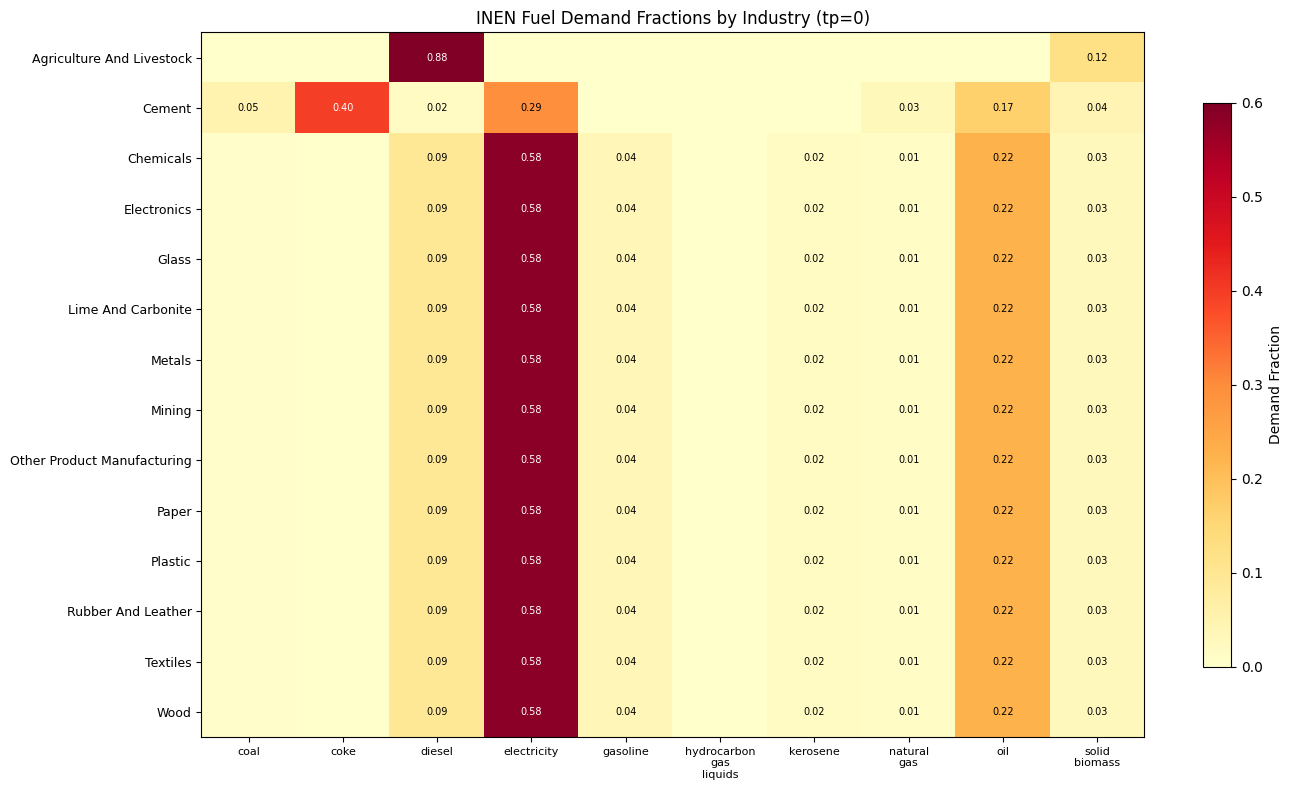

In [24]:
# === PLOT 6: Fuel Fraction Heatmap — All Industries ===
# Rows = industries, Columns = fuels, Values = demand fraction at tp=0

industries = ['agriculture_and_livestock', 'cement', 'chemicals', 'electronics',
              'glass', 'lime_and_carbonite', 'metals', 'mining',
              'other_product_manufacturing', 'paper', 'plastic',
              'rubber_and_leather', 'textiles', 'wood']
fuels = ['coal', 'coke', 'diesel', 'electricity', 'gasoline',
         'hydrocarbon_gas_liquids', 'kerosene', 'natural_gas', 'oil', 'solid_biomass']

matrix = np.zeros((len(industries), len(fuels)))
for i, ind in enumerate(industries):
    for j, fuel in enumerate(fuels):
        col = f'frac_inen_energy_{ind}_{fuel}'
        if col in df.columns:
            matrix[i, j] = df[col].iloc[0]

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.6)
ax.set_xticks(range(len(fuels)))
ax.set_xticklabels([f.replace('_', '\n') for f in fuels], fontsize=8, rotation=0, ha='center')
ax.set_yticks(range(len(industries)))
ax.set_yticklabels([i.replace('_', ' ').title() for i in industries], fontsize=9)

# Add value annotations
for i in range(len(industries)):
    for j in range(len(fuels)):
        v = matrix[i, j]
        if v > 0.005:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if v > 0.3 else 'black')

plt.colorbar(im, ax=ax, shrink=0.8, label='Demand Fraction')
ax.set_title('INEN Fuel Demand Fractions by Industry (tp=0)')
plt.tight_layout()
plt.show()

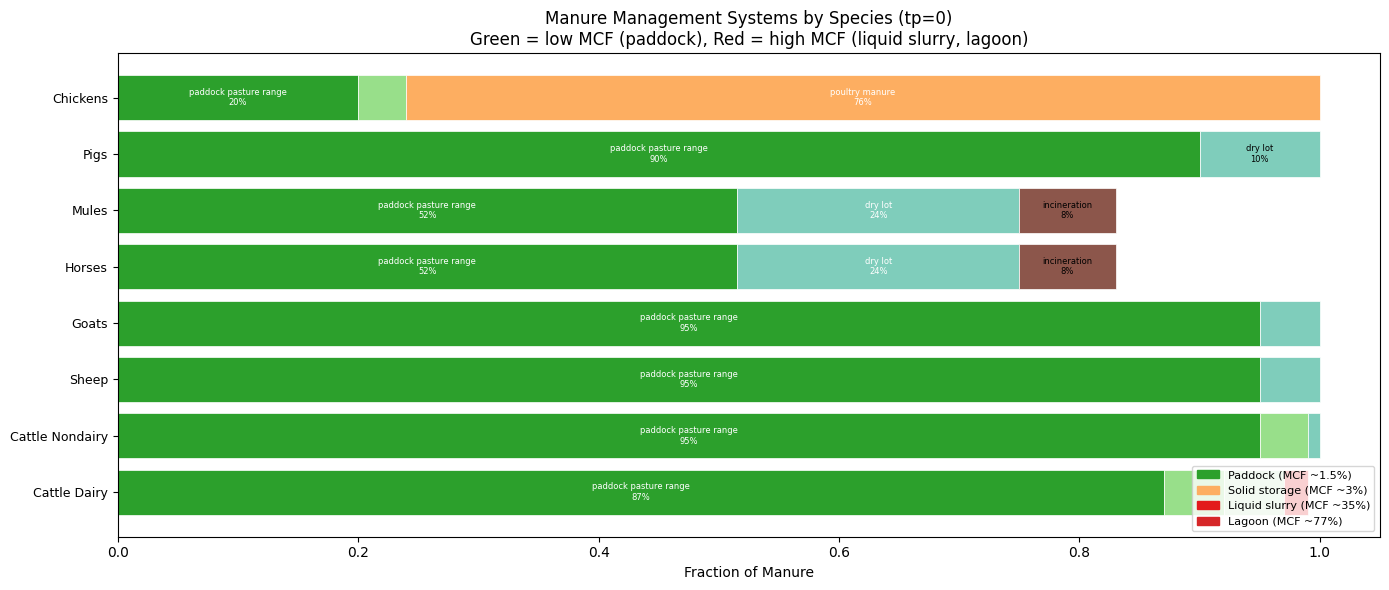

In [25]:
# === PLOT 7: Manure Management by Species ===
# Stacked bars colored by MCF impact (green=low, red=high)

MCF_COLORS = {
    'paddock_pasture_range': '#2ca02c',   # MCF ~1.5% (green = low impact)
    'daily_spread': '#98df8a',            # MCF ~0.1%
    'dry_lot': '#7fcdbb',                 # MCF ~1-5%
    'composting': '#c7e9c0',              # MCF ~0.5%
    'storage_solid': '#fdae61',           # MCF ~2-4% (yellow = moderate)
    'deep_bedding': '#fee08b',            # MCF ~3-5%
    'poultry_manure': '#fdae61',          # MCF ~1.5%
    'liquid_slurry': '#e31a1c',           # MCF ~35% at 18°C (RED = high impact!)
    'anaerobic_lagoon': '#d62728',        # MCF ~77% (RED)
    'anaerobic_digester': '#9467bd',      # Biogas capture (purple = managed)
    'incineration': '#8c564b',            # Combustion
}

species = ['cattle_dairy', 'cattle_nondairy', 'sheep', 'goats', 'horses', 'mules', 'pigs', 'chickens']
systems = list(MCF_COLORS.keys())

fig, ax = plt.subplots(figsize=(14, 6))
y_pos = range(len(species))

for s_idx, sp in enumerate(species):
    left = 0
    for sys in systems:
        col = f'frac_lvst_mm_{sp}_{sys}'
        if col in df.columns:
            v = df[col].iloc[0]
            if v > 0.005:
                ax.barh(s_idx, v, left=left, color=MCF_COLORS.get(sys, '#999'),
                        edgecolor='white', linewidth=0.5)
                if v > 0.05:
                    ax.text(left + v/2, s_idx, f'{sys.replace("_"," ")}\n{v:.0%}',
                            ha='center', va='center', fontsize=6, color='white' if v > 0.15 else 'black')
                left += v

ax.set_yticks(y_pos)
ax.set_yticklabels([s.replace('_', ' ').title() for s in species], fontsize=9)
ax.set_xlabel('Fraction of Manure')
ax.set_title('Manure Management Systems by Species (tp=0)\nGreen = low MCF (paddock), Red = high MCF (liquid slurry, lagoon)')
ax.set_xlim(0, 1.05)

# Simplified legend
from matplotlib.patches import Patch
legend_items = [
    Patch(color='#2ca02c', label='Paddock (MCF ~1.5%)'),
    Patch(color='#fdae61', label='Solid storage (MCF ~3%)'),
    Patch(color='#e31a1c', label='Liquid slurry (MCF ~35%)'),
    Patch(color='#d62728', label='Lagoon (MCF ~77%)'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

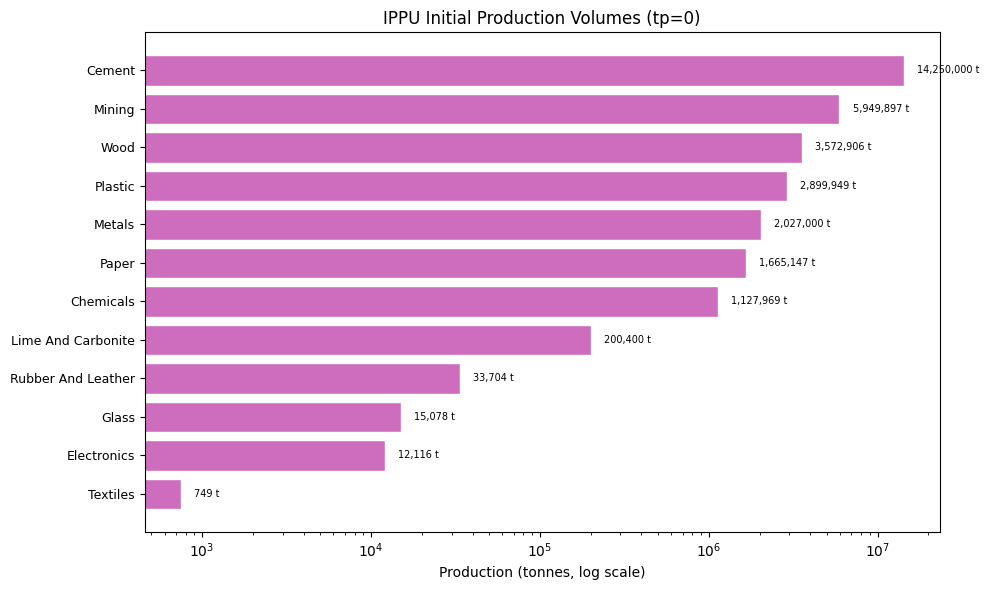

In [26]:
# === PLOT 8: IPPU Production Volumes (log scale) ===

prod_cols = [c for c in df.columns if c.startswith('prodinit_ippu_') and '_tonne' in c]
prod_data = {c.replace('prodinit_ippu_', '').replace('_tonne', '').replace('_', ' ').title(): df[c].iloc[0]
             for c in prod_cols if df[c].iloc[0] > 0}

if prod_data:
    sorted_prods = sorted(prod_data.items(), key=lambda x: x[1])
    names, vals = zip(*sorted_prods)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(range(len(names)), vals, color='#CE6DBD', edgecolor='white')
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xscale('log')
    ax.set_xlabel('Production (tonnes, log scale)')
    ax.set_title('IPPU Initial Production Volumes (tp=0)')
    
    for i, v in enumerate(vals):
        ax.text(v * 1.2, i, f'{v:,.0f} t', va='center', fontsize=7)
    
    plt.tight_layout()
    plt.show()

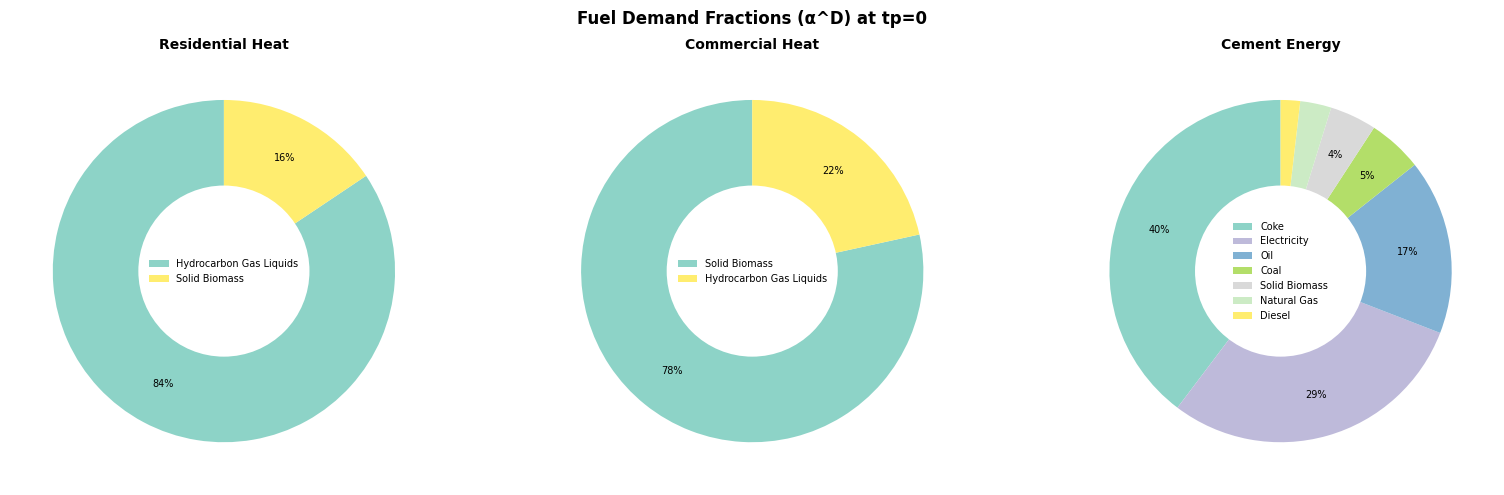

In [27]:
# === PLOT 9: SCOE + INEN Fuel Mix Comparison (donut charts) ===
# Side-by-side donuts for residential heat, commercial heat, and cement

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ['Residential Heat', 'Commercial Heat', 'Cement Energy']
prefixes = ['frac_scoe_heat_energy_residential_', 'frac_scoe_heat_energy_commercial_municipal_', 'frac_inen_energy_cement_']

for ax, title, prefix in zip(axes, titles, prefixes):
    cols = [c for c in df.columns if c.startswith(prefix)]
    vals = {c.replace(prefix, '').replace('_', ' ').title(): df[c].iloc[0] for c in cols if df[c].iloc[0] > 0.005}
    
    if vals:
        labels, sizes = zip(*sorted(vals.items(), key=lambda x: -x[1]))
        colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))
        wedges, texts, autotexts = ax.pie(sizes, labels=None, autopct=lambda p: f'{p:.0f}%' if p > 3 else '',
                                           colors=colors, pctdistance=0.75, startangle=90)
        # Donut hole
        centre_circle = plt.Circle((0, 0), 0.5, fc='white')
        ax.add_artist(centre_circle)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.legend(labels, loc='center', fontsize=7, frameon=False)
        for t in autotexts:
            t.set_fontsize(7)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center')
        ax.set_title(title)

fig.suptitle('Fuel Demand Fractions (α^D) at tp=0', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

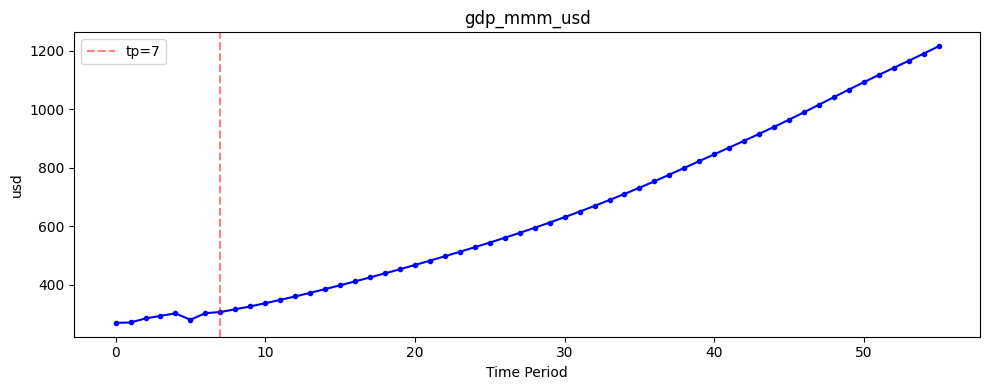

In [28]:
def plot_parameter(column_name):
    """Plot a parameter over all time periods."""
    if column_name not in df.columns:
        print(f"Column '{column_name}' not found")
        return
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(range(N_TP), df[column_name], 'b-o', markersize=3)
    ax.axvline(CALIBRATION_TP, color='red', linestyle='--', alpha=0.5, label=f'tp={CALIBRATION_TP}')
    ax.set_xlabel('Time Period')
    ax.set_ylabel(column_name.split('_')[-1])
    ax.set_title(column_name)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_parameter("gdp_mmm_usd")

---
# Section 5: Fix Workflow

**The golden rule: Scale, Don't Replace.**

`factor = target_value / current_value_at_tp7`

Multiply the entire column by this factor. This preserves the trajectory shape while correcting the level.

In [42]:
def calculate_scaling(column, target_value, ref_tp=CALIBRATION_TP):
    """Preview a scaling factor without applying it."""
    current = df[column].iloc[ref_tp]
    if abs(current) < 1e-10:
        print(f"  WARNING: {column} is near zero at tp={ref_tp}. Cannot scale.")
        return None
    factor = target_value / current
    print(f"  Column:  {column}")
    print(f"  Current: {current:.6g} at tp={ref_tp}")
    print(f"  Target:  {target_value:.6g}")
    print(f"  Factor:  {factor:.4f}")
    if abs(factor) > 10 or abs(factor) < 0.1:
        print(f"  WARNING: factor {factor:.2f} is extreme (>10x or <0.1x). Double-check.")
    return factor

calculate_scaling("pop_lvst_initial_sheep", 20_000_000)

  Column:  pop_lvst_initial_sheep
  Current: 2.18006e+07 at tp=7
  Target:  2e+07
  Factor:  0.9174


np.float64(0.9174077945534967)

In [43]:
def apply_scaling(column, target_value, ref_tp=CALIBRATION_TP):
    """Apply scaling factor to preserve trajectory shape."""
    factor = calculate_scaling(column, target_value, ref_tp)
    if factor is not None:
        df[column] *= factor
        print(f"  Applied. New value at tp={ref_tp}: {df[column].iloc[ref_tp]:.6g}")
    return factor

def rebalance_fractions(prefix, target_col, target_value):
    """Set one fraction and proportionally rescale others to sum to 1.0."""
    cols = [c for c in df.columns if c.startswith(prefix)]
    others = [c for c in cols if c != target_col]
    old_others_sum = df[others].sum(axis=1)
    df[target_col] = target_value
    mask = old_others_sum > 1e-10
    df.loc[mask, others] = df.loc[mask, others].mul((1 - target_value) / old_others_sum[mask], axis=0)
    df.loc[~mask, others] = (1 - target_value) / len(others)
    new_sum = df[cols].sum(axis=1)
    print(f"  Rebalanced {prefix}*: sum range {new_sum.min():.6f} – {new_sum.max():.6f}")

In [ ]:
def save_input_csv():
    """Save df_input_0.csv with backup."""
    csv_path = INPUT_DIR / 'df_input_0.csv'
    backup = INPUT_DIR / f'df_input_0.csv.bak_{datetime.now().strftime("%Y%m%d_%H%M%S")}'
    if csv_path.exists():
        import shutil
        shutil.copy(csv_path, backup)
        print(f"  Backup: {backup.name}")
    n_inf = sum(np.isinf(df[c]).sum() for c in df.select_dtypes(include=[np.number]).columns)
    n_nan = df.isna().sum().sum()
    print(f"  Validation: inf={n_inf}, NaN={n_nan}")
    if n_nan > 0:
        df.fillna(0, inplace=True)
        print(f"  Filled {n_nan} NaN values with 0")
    df.to_csv(csv_path, index=False)
    print(f"  Saved to {csv_path.name}")

#  save_input_csv()

---
# Section 6: Iteration Tracker

Track calibration progress across multiple runs. Detect regressions (a sector getting worse after a fix).

**Stopping rules:**
- No fix improves total error by > 0.5 MtCO2e
- Oscillation detected (sector improves then worsens)
- All remaining gaps are structural (documented)

In [32]:
# List all calibration runs
runs = sorted(OUTPUT_DIR.glob('calibration_*'))
print(f"Found {len(runs)} calibration runs:")
progress = []
for run_dir in runs[-10:]:
    diag_file = run_dir / 'diagnostics' / 'diff_report.csv'
    if diag_file.exists():
        d = pd.read_csv(diag_file)
        sig = d[d['inventory'].abs() > 0.01]
        total = sig['diff'].abs().sum()
        n15 = (sig['error_pct'] <= 15).sum()
        progress.append({'run': run_dir.name, 'total_error': total, 'within_15pct': n15, 'categories': len(sig)})
        print(f"  {run_dir.name}: {total:.2f} MtCO2e | {n15}/{len(sig)} within 15%")
    else:
        print(f"  {run_dir.name}: (no diagnostics)")

if progress:
    prog_df = pd.DataFrame(progress)

Found 140 calibration runs:
  calibration_20260313_194343: 7.29 MtCO2e | 16/34 within 15%
  calibration_20260313_194725: 7.29 MtCO2e | 16/34 within 15%
  calibration_20260313_195841: 7.29 MtCO2e | 16/34 within 15%
  calibration_20260313_201747: 7.29 MtCO2e | 16/34 within 15%
  calibration_20260313_211343: 7.29 MtCO2e | 16/34 within 15%
  calibration_20260313_215912: 7.29 MtCO2e | 16/34 within 15%
  calibration_20260313_220413: 7.29 MtCO2e | 16/34 within 15%
  calibration_20260313_221438: 7.29 MtCO2e | 16/34 within 15%
  calibration_20260313_223246: 7.29 MtCO2e | 16/34 within 15%
  calibration_20260313_224517: 7.29 MtCO2e | 16/34 within 15%


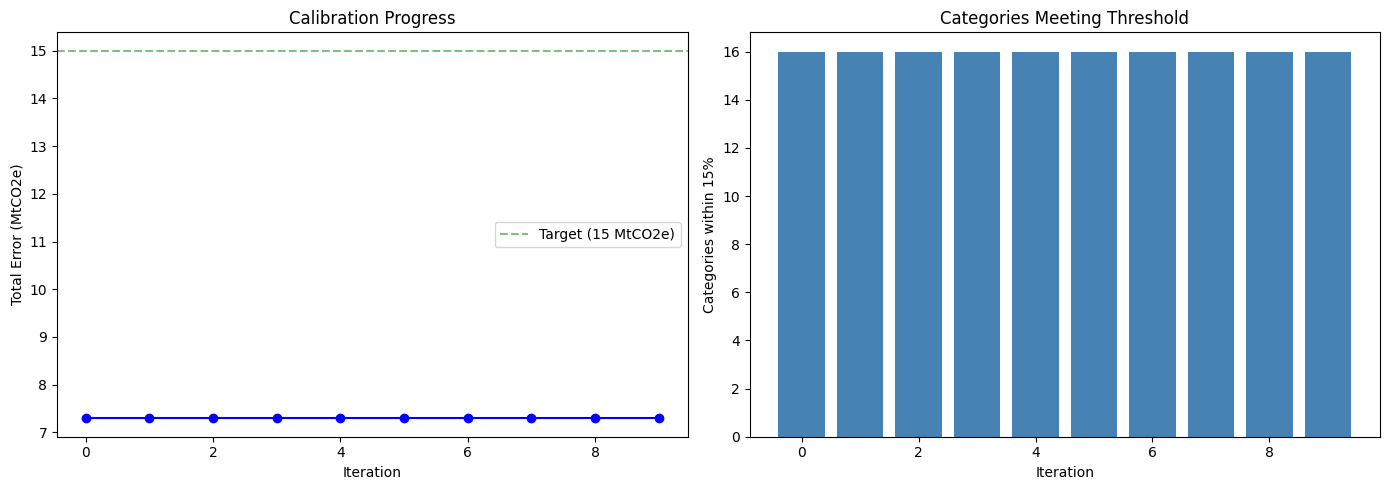

In [33]:
# Progress chart
if progress and len(progress) > 1:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(range(len(progress)), [p['total_error'] for p in progress], 'bo-')
    ax1.axhline(15, color='green', linestyle='--', alpha=0.5, label='Target (15 MtCO2e)')
    ax1.set_xlabel('Iteration')
    ax1.set_ylabel('Total Error (MtCO2e)')
    ax1.set_title('Calibration Progress')
    ax1.legend()

    ax2.bar(range(len(progress)), [p['within_15pct'] for p in progress], color='steelblue')
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Categories within 15%')
    ax2.set_title('Categories Meeting Threshold')
    plt.tight_layout()
    plt.show()
else:
    print("Need 2+ runs for progress chart.")

---
# Section 7: Reference Data Browser

**Reference hierarchy:**
1. NIR / National Inventory (authoritative for targets)
2. SNBC / NDC (official BAU projections)
3. IEA (energy data)
4. EDGAR v8.0 (cross-check only — known errors in waste CH4, soil N2O, HFC)
5. FAO / World Bank (socioeconomic)
6. IPCC tables (emission factors, MCFs)

In [34]:
# FAO Livestock
fao_files = sorted(EXTERNAL_DIR.glob('fao/*.csv'))
print(f"FAO files: {len(fao_files)}")
for f in fao_files:
    print(f"  {f.name}")

if any('livestock' in f.name.lower() and 'pattern' in f.name.lower() for f in fao_files):
    livestock_file = [f for f in fao_files if 'livestock' in f.name.lower() and 'pattern' in f.name.lower()][0]
    fao_livestock = pd.read_csv(livestock_file)
    print(f"\nFAO Livestock Patterns: {len(fao_livestock)} rows")
    print(fao_livestock.head())

FAO files: 7
  morocco_emissions_crops_2015_2022.csv
  morocco_emissions_livestock_2015_2022.csv
  morocco_emissions_totals_2015_2022.csv
  morocco_fertilizers_nutrient_2015_2022.csv
  morocco_livestock_manure_2015_2022.csv
  morocco_livestock_patterns_2015_2022.csv
  morocco_production_crops_livestock_2015_2022.csv

FAO Livestock Patterns: 312 rows
   Area Code Area Code (M49)     Area  Item Code Item Code (CPC)   Item  \
0        143            '504  Morocco       1107          '02132  Asses   
1        143            '504  Morocco       1107          '02132  Asses   
2        143            '504  Morocco       1107          '02132  Asses   
3        143            '504  Morocco       1107          '02132  Asses   
4        143            '504  Morocco       1107          '02132  Asses   

   Element Code                                     Element  Year Code  Year  \
0          7213  Livestock units per agricultural land area       2015  2015   
1          7213  Livestock units per 

In [35]:
# IPCC tables
ipcc_dir = PROJECT_DIR / 'ipcc_tables'
if ipcc_dir.exists():
    ipcc_files = sorted(ipcc_dir.glob('*.csv'))
    print(f"IPCC tables: {len(ipcc_files)}")
    for f in ipcc_files:
        print(f"  {f.name}")
else:
    print("No ipcc_tables/ directory found")

IPCC tables: 14
  V2_Ch2_Table2.2_fuel_CO2_EFs.csv
  V4_Ch10_Table10.10_enteric_EF_cattle.csv
  V4_Ch10_Table10.10_enteric_EF_cattle_cont.csv
  V4_Ch10_Table10.10_enteric_EF_noncattle.csv
  V4_Ch10_Table10.11_enteric_EF_other.csv
  V4_Ch10_Table10.12_body_mass.csv
  V4_Ch10_Table10.17_manure_MCF_by_temp.csv
  V4_Ch10_Table10.19_N_excretion.csv
  V4_Ch10_page28_enteric_EFs.csv
  V4_Ch11_Table11.1_direct_N2O_EFs.csv
  V4_Ch11_Table11.3_volatilisation_leaching.csv
  V4_Ch2_Table2.3_SOC_reference.csv
  V5_Ch3_Table3.1_MCF.csv
  V5_Ch3_Table3.3_decay_rates.csv


In [36]:
# Targets summary
if targets is not None:
    # The CSV has a country code column (e.g., 'MAR'), not 'inventory'
    standard = {'subsector_ssp','sector','subsector','category',
                'aggregation_category','gas','ID','vars','ids','target_source','description','fixability','notes'}
    val_col = [c for c in targets.columns if c not in standard][-1]
    
    print(f"Inventory targets ({TARGETS_FILE.name}, column '{val_col}'):")
    for sec in sorted(targets['sector'].unique()):
        sub = targets[targets['sector'] == sec]
        total = sub[val_col].sum()
        print(f"  {sec:35s}: {total:8.3f} MtCO2e ({len(sub)} categories)")
    print(f"  {'TOTAL':35s}: {targets[val_col].sum():8.3f} MtCO2e")

Inventory targets (emission_targets_mar_2022.csv, column 'MAR'):
  1 - Energy                         :   68.508 MtCO2e (21 categories)
  2 - IPPU                           :    5.822 MtCO2e (6 categories)
  3 - AFOLU                          :   18.498 MtCO2e (7 categories)
  4 - Waste                          :    6.673 MtCO2e (3 categories)
  5 - CCSQ                           :    0.000 MtCO2e (1 categories)
  TOTAL                              :   99.501 MtCO2e


---
# Section 8: DAG Explorer

SISEPUEDE runs sectors in a fixed order. Changing parameters in one sector can cascade to downstream sectors.

```
Socioeconomic (population, GDP, HH count) → feeds ALL sectors

Step 1: AFOLU (LNDU → FRST → AGRC → LVST → LSMM → SOIL)
  → CircularEconomy (food loss → MSW), EnergyConsumption (crop yield), EnergyProduction (biogas)
Step 2: CircularEconomy (WALI → TRWW → WASO) → IPPU, EnergyProduction
Step 3: IPPU (cement, HFC, metals) → EnergyConsumption (production volumes)
Step 4: EnergyConsumption (CCSQ → INEN → SCOE → TRNS) → EnergyProduction (fuel demand)
Step 5: EnergyProduction (NemoMod LP: ENTC + ENFU) → FugitiveEmissions
Step 6: FugitiveEmissions (FGTV) — terminal
```

**Before fixing any sector, trace upstream (is the error inherited?) and downstream (what else will move?).**

In [37]:
from compare_to_inventory import DAG_AFFECTS

def trace_upstream(subsector):
    """What feeds this subsector?"""
    upstream = [k for k, v in DAG_AFFECTS.items() if subsector in v]
    print(f"Upstream of {subsector}: {upstream if upstream else '(none — root sector)'}")
    return upstream

def trace_downstream(subsector):
    """What does this subsector affect?"""
    downstream = DAG_AFFECTS.get(subsector, [])
    print(f"Downstream of {subsector}: {downstream if downstream else '(terminal node)'}")
    return downstream

trace_upstream("entc")
trace_downstream("entc")
print()
trace_upstream("lvst")
trace_downstream("lvst")

Upstream of entc: ['lsmm', 'agrc', 'waso', 'trww', 'ippu', 'inen', 'scoe', 'trns']
Downstream of entc: ['fgtv']

Upstream of lvst: (none — root sector)
Downstream of lvst: ['lsmm', 'soil', 'lndu', 'agrc', 'waso', 'inen']


['lsmm', 'soil', 'lndu', 'agrc', 'waso', 'inen']

In [38]:
def predict_cascade(subsector):
    """Show the full cascade from a subsector change."""
    visited = set()
    queue = [subsector]
    path = []
    while queue:
        current = queue.pop(0)
        if current in visited:
            continue
        visited.add(current)
        affected = DAG_AFFECTS.get(current, [])
        for a in affected:
            path.append(f"  {current} → {a}")
            queue.append(a)
    if path:
        print(f"Cascade from changing {subsector}:")
        for p in path:
            print(p)
    else:
        print(f"{subsector} is a terminal node (no downstream effects)")

predict_cascade("lvst")

Cascade from changing lvst:
  lvst → lsmm
  lvst → soil
  lvst → lndu
  lvst → agrc
  lvst → waso
  lvst → inen
  lsmm → soil
  lsmm → entc
  lndu → frst
  lndu → soil
  lndu → agrc
  agrc → soil
  agrc → inen
  agrc → entc
  agrc → waso
  waso → entc
  waso → ippu
  inen → entc
  inen → fgtv
  entc → fgtv
  ippu → inen
  ippu → entc


In [ ]:
# === DAG PLOT A: Calibration Error Attribution Waterfall ===
# Shows WHERE the model-inventory gap comes from, subsector by subsector.
# Red = overshoot, Blue = undershoot. Sorted by absolute error.

# Setup shared variables for all DAG plots
tp7 = wide[wide['time_period'] == CALIBRATION_TP].iloc[0]

SECTOR_COLORS_DAG = {
    'agrc': '#8C6D31', 'frst': '#31A354', 'lndu': '#B5CF6B',
    'lsmm': '#E7BA52', 'lvst': '#BD9E39', 'soil': '#8C6D31',
    'waso': '#843C39', 'trww': '#D6616B',
    'ccsq': '#C6DBEF', 'entc': '#6B6ECF', 'fgtv': '#393B79',
    'inen': '#3182BD', 'scoe': '#6BAED6', 'trns': '#756BB1',
    'ippu': '#CE6DBD',
}

emissions = {}
for s in SUBSECTOR_NAMES:
    col = f'emission_co2e_subsector_total_{s}'
    emissions[s] = abs(tp7.get(col, 0.1))

# Build diff report from targets + wide
rows = []
for _, row in targets.iterrows():
    vl = [v.strip() for v in str(row.get('vars', '')).split(':') if v.strip()]
    model_val = sum(tp7.get(v, 0) for v in vl if v in tp7.index)
    inv = row[val_col] if val_col in row.index else row.get('inventory', 0)
    rows.append({'ID': row['ID'], 'subsector': row.get('subsector_ssp', ''),
                 'inventory': inv, 'model': model_val})
dr = pd.DataFrame(rows)
dr['diff'] = dr['model'] - dr['inventory']

# Aggregate by subsector
sub_err = dr.groupby('subsector').agg(
    inventory=('inventory', 'sum'), model=('model', 'sum'), diff=('diff', 'sum')
).reset_index()
sub_err['abs_diff'] = sub_err['diff'].abs()
sub_err = sub_err[sub_err['abs_diff'] > 0.01].sort_values('abs_diff', ascending=True)

fig, ax = plt.subplots(figsize=(12, max(5, len(sub_err) * 0.45)))
colors = ['#F44336' if d > 0 else '#2196F3' for d in sub_err['diff']]
ax.barh(range(len(sub_err)), sub_err['diff'].values, color=colors,
        edgecolor='white', linewidth=0.5, alpha=0.85)

for i, (_, row) in enumerate(sub_err.iterrows()):
    name = SUBSECTOR_NAMES.get(row['subsector'], row['subsector'])
    ax.text(-0.3, i, name, ha='right', va='center', fontsize=9, fontweight='bold')
    side = 'left' if row['diff'] < 0 else 'right'
    offset = -0.1 if row['diff'] < 0 else 0.1
    ax.text(row['diff'] + offset, i,
            f"{row['diff']:+.1f} Mt  ({row['inventory']:.1f}\u2192{row['model']:.1f})",
            ha=side, va='center', fontsize=7, color='#333')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks([])
ax.set_xlabel('Model \u2212 Inventory (MtCO\u2082e)')
total_err = sub_err['diff'].abs().sum()
ax.set_title(f'Calibration Error Attribution by Subsector (tp={CALIBRATION_TP})\n'
             f'Total absolute error: {total_err:.1f} MtCO\u2082e. '
             f'Red = overshoot, Blue = undershoot.',
             fontweight='bold', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# === DAG PLOT B: Calibration Priority — Error vs Inventory Share ===
# x = share of total inventory, y = relative error, size = absolute error.
# Top-right = high impact + high error = fix first.

rows = []
for _, row in targets.iterrows():
    vl = [v.strip() for v in str(row.get('vars', '')).split(':') if v.strip()]
    model_val = sum(tp7.get(v, 0) for v in vl if v in tp7.index)
    inv = row[val_col] if val_col in row.index else row.get('inventory', 0)
    rows.append({'ID': row['ID'], 'category': row.get('category', row['ID']),
                 'inventory': inv, 'model': model_val})
dr = pd.DataFrame(rows)
dr['diff'] = dr['model'] - dr['inventory']

total_inv = dr['inventory'].abs().sum()
dr['inv_share'] = dr['inventory'].abs() / total_inv * 100
dr['error_pct'] = (dr['diff'].abs() / dr['inventory'].abs().clip(lower=0.01) * 100).clip(upper=200)
dr['abs_diff'] = dr['diff'].abs()

sig = dr[dr['inventory'].abs() > 0.05].copy()

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#F44336' if d > 0 else '#2196F3' for d in sig['diff']]
sizes = sig['abs_diff'].clip(lower=0.1) * 40

ax.scatter(sig['inv_share'], sig['error_pct'], s=sizes, c=colors, alpha=0.6, edgecolors='white', linewidth=0.5)

for _, row in sig.nlargest(10, 'abs_diff').iterrows():
    label = row['ID'] if len(str(row.get('category', ''))) > 30 else str(row.get('category', row['ID']))
    ax.annotate(label[:25], (row['inv_share'], row['error_pct']),
                fontsize=7, ha='left', va='bottom', xytext=(5, 5), textcoords='offset points')

ax.axhline(25, color='orange', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(15, color='green', linestyle='--', alpha=0.5, linewidth=1)
ax.text(ax.get_xlim()[1] * 0.95, 12, '15% threshold', ha='right', fontsize=7, color='green')
ax.text(ax.get_xlim()[1] * 0.95, 27, '25% threshold', ha='right', fontsize=7, color='orange')

ax.set_xlabel('Share of Total Inventory (%)', fontsize=10)
ax.set_ylabel('Relative Error (%)', fontsize=10)
ax.set_title(f'Calibration Priority Map (tp={CALIBRATION_TP})\n'
             f'Bubble size = absolute error. Red = overshoot, Blue = undershoot.\n'
             f'Top-right = high impact + high error \u2192 fix first.',
             fontweight='bold', fontsize=11)
ax.grid(alpha=0.3)
ax.set_ylim(-5, min(sig['error_pct'].max() * 1.1, 210))

from matplotlib.lines import Line2D
legend = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#F44336', markersize=10, label='Overshoot'),
          Line2D([0], [0], marker='o', color='w', markerfacecolor='#2196F3', markersize=10, label='Undershoot')]
ax.legend(handles=legend, loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# === DAG PLOT C: Sankey Diagram — Structure + Magnitude ===
# Derived from DAG_AFFECTS and DAG_ORDER (single source of truth).
# Flow width proportional to source-node emission magnitude.
import plotly.graph_objects as go
from compare_to_inventory import DAG_AFFECTS, DAG_ORDER

# Normalize layer numbers to 0-based
min_layer = min(DAG_ORDER.values())
layers = {s: v - min_layer for s, v in DAG_ORDER.items()}
max_layer = max(layers.values())

LAYER_LABELS = {0: 'AFOLU', 1: 'Waste', 2: 'IPPU', 3: 'Energy Demand', 4: 'Energy Production', 5: 'Fugitive', 6: 'CCS'}

# Derive forward edges from DAG_AFFECTS (cross-layer only for clean Sankey)
sankey_edges = []
for src, tgts in DAG_AFFECTS.items():
    for tgt in tgts:
        if tgt in layers and src in layers and layers[tgt] > layers[src]:
            sankey_edges.append((src, tgt))

# Auto-compute Y positions: sort by emission within each layer, spread evenly
layer_groups = {}
for s, l in layers.items():
    layer_groups.setdefault(l, []).append(s)

y_pos = {}
for layer, group in layer_groups.items():
    sorted_nodes = sorted(group, key=lambda s: -emissions.get(s, 0))
    n = len(sorted_nodes)
    for i, s in enumerate(sorted_nodes):
        y_pos[s] = 0.05 + i * (0.90 / max(n - 1, 1)) if n > 1 else 0.5

# Build Sankey data
nodes = [s for s in SUBSECTOR_NAMES if s in layers]
node_idx = {s: i for i, s in enumerate(nodes)}
node_x = [0.01 + layers[s] * (0.95 / max(max_layer, 1)) for s in nodes]
node_y = [y_pos.get(s, 0.5) for s in nodes]

sources, targets, values, link_colors = [], [], [], []
for src, tgt in sankey_edges:
    if src not in node_idx or tgt not in node_idx:
        continue
    flow = max(emissions.get(src, 0.01) * 0.25, 0.08)
    sources.append(node_idx[src])
    targets.append(node_idx[tgt])
    values.append(flow)
    hex_c = SECTOR_COLORS_DAG.get(src, '#999')
    r, g, b = int(hex_c[1:3], 16), int(hex_c[3:5], 16), int(hex_c[5:7], 16)
    link_colors.append(f'rgba({r},{g},{b},0.35)')

fig = go.Figure(go.Sankey(
    arrangement='fixed',
    node=dict(
        pad=15, thickness=20,
        line=dict(color='white', width=1),
        label=[f'{SUBSECTOR_NAMES[s]}<br>{emissions.get(s, 0):.1f} Mt' for s in nodes],
        color=[SECTOR_COLORS_DAG.get(s, '#999') for s in nodes],
        x=node_x, y=node_y,
    ),
    link=dict(source=sources, target=targets, value=values, color=link_colors),
))

# Step labels at bottom
for layer_num in sorted(set(layers.values())):
    label = LAYER_LABELS.get(layer_num, f'Step {layer_num+1}')
    fig.add_annotation(
        x=0.01 + layer_num * (0.95 / max(max_layer, 1)), y=-0.06,
        text=f'<b>Step {layer_num+1}</b>: {label}',
        showarrow=False, font=dict(size=9, color='gray'),
        xref='paper', yref='paper',
    )

fig.update_layout(
    title=dict(
        text='SISEPUEDE DAG: Emission Flow by Sector Dependency<br>'
             '<sub>Flow width proportional to upstream emission magnitude. '
             f'Derived from DAG_AFFECTS ({len(sankey_edges)} cross-layer edges).</sub>',
        font=dict(size=14),
    ),
    font=dict(size=10), width=1200, height=650,
    margin=dict(l=20, r=20, t=60, b=50),
)
fig.show()

---
*End of calibration workflow notebook. See `morocco_calibration_guide.md` for the full theoretical background.*